In [38]:
# Data import & Preparation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

movies = pd.read_csv(r"Documents/Learnable/movies_dataset.csv")
movies

,title,release_year,genre,runtime,rating
0,Crimson Horizon,2011,Comedy,121.0,8.1
1,Laughing Shadows,2012,Action,101.0,7.6
2,Broken Silence,2016,Comedy,140.0,8.2
3,Iron Pursuit,2013,Drama,145.0,6.3
4,Hearts in Bloom,2015,Horror,NaN,5.3
...,...,...,...,...,...
195,Warp Speed 126 195,2009,Horror,158.0,6.0
196,Stellar Gate 64 83 86 196,2015,Romance,151.0,6.2
197,Velocity Rush 61 108 197,2016,Comedy,121.0,8.4
198,Endless Promise 198,2011,Drama,129.0,6.2


In [39]:
movies.head(10)      # Exploring the DataFrame

,title,release_year,genre,runtime,rating
0,Crimson Horizon,2011,Comedy,121.0,8.1
1,Laughing Shadows,2012,Action,101.0,7.6
2,Broken Silence,2016,Comedy,140.0,8.2
3,Iron Pursuit,2013,Drama,145.0,6.3
4,Hearts in Bloom,2015,Horror,NaN,5.3
5,Midnight Howl,2013,Sci-Fi,153.0,8.2
6,Fading Echoes,2020,Comedy,92.0,7.2
7,Comic Relief,2021,Horror,90.0,5.7
8,Storm Protocol,2018,Sci-Fi,91.0,8.7
9,Galactic Drift,2012,Sci-Fi,115.0,7.0


In [36]:
movies.info()            # Exploring the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         200 non-null    object 
 1   release_year  200 non-null    int64  
 2   genre         200 non-null    object 
 3   runtime       191 non-null    float64
 4   rating        0 non-null      float64
dtypes: float64(2), int64(1), object(2)
memory usage: 7.9+ KB


In [35]:
movies.describe()                  # Exploring the DataFrame

,release_year,runtime,rating
count,200.000000,191.00000,191.000000
mean,2015.035000,122.04712,6.995288
std,4.037982,21.76871,1.064315
min,2008.000000,85.00000,5.000000
25%,2012.000000,104.00000,6.100000
50%,2015.000000,121.00000,7.000000
75%,2018.000000,141.00000,7.950000
max,2021.000000,160.00000,8.700000


In [40]:
# Handling missing values

movies.isnull().sum()                    

title           0
release_year    0
genre           0
runtime         9
rating          9
dtype: int64

In [6]:
movies[movies.isnull().any(axis=1)]

,title,release_year,genre,runtime,rating
4,Hearts in Bloom,2015,Horror,NaN,5.3
10,Silent Verdict,2012,Comedy,125.0,NaN
11,Weekend Chaos,2021,Action,112.0,NaN
13,Endless Promise,2014,Sci-Fi,NaN,NaN
16,Shattered Truth,2010,Comedy,102.0,NaN
18,Final Strike,2016,Romance,88.0,NaN
19,Love Again,2019,Romance,117.0,NaN
42,Battle Line,2015,Drama,NaN,7.2
52,Deep Regret 52,2016,Sci-Fi,90.0,NaN
58,Love Letters 58,2010,Action,NaN,7.0


In [11]:
# Checking for both mean & median to be sure there's no outlier before populating with mean

avg_rating= movies['rating'].mean()             
avg_rating

np.float64(6.995287958115183)

In [12]:
median= movies['rating'].median()
median

7.0

In [16]:
avg_runtime= movies['runtime'].mean()
avg_runtime

np.float64(122.04712041884817)

In [15]:
median2= movies['runtime'].median()
median2

121.0

In [41]:
# Since there's both mean & median are approximately same, I populate with the means

movies['rating']= movies['rating'].fillna(7.0)

In [42]:
movies['runtime']= movies['runtime'].fillna(122.0)

In [43]:
movies.isnull().sum()

title           0
release_year    0
genre           0
runtime         0
rating          0
dtype: int64

In [45]:
movies.info()                    # Datatypes are in order(no need to change)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         200 non-null    object 
 1   release_year  200 non-null    int64  
 2   genre         200 non-null    object 
 3   runtime       200 non-null    float64
 4   rating        200 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 7.9+ KB


In [46]:
# Calculate the average runtime of movies in each genre using np.mean() and groupby 

average_runtime= movies.groupby('genre')['runtime'].mean()             
print(average_runtime)

genre
Action     125.862069
Comedy     122.333333
Drama      125.606061
Horror     128.545455
Romance    116.594595
Sci-Fi     114.187500
Name: runtime, dtype: float64


In [47]:
#  Movie with the longest runtime using np.argmax()

longest_runtime= np.argmax(movies['runtime'])              
longest_runtime

np.int64(38)

In [48]:
# Create a new column for "movie age" by calculating the difference between the current year and the release year

from datetime import date
current_year= date.today().year
current_year

2026

In [49]:
movies['movie_age']= current_year - movies['release_year']
movies

,title,release_year,genre,runtime,rating,movie_age
0,Crimson Horizon,2011,Comedy,121.0,8.1,15
1,Laughing Shadows,2012,Action,101.0,7.6,14
2,Broken Silence,2016,Comedy,140.0,8.2,10
3,Iron Pursuit,2013,Drama,145.0,6.3,13
4,Hearts in Bloom,2015,Horror,122.0,5.3,11
...,...,...,...,...,...,...
195,Warp Speed 126 195,2009,Horror,158.0,6.0,17
196,Stellar Gate 64 83 86 196,2015,Romance,151.0,6.2,11
197,Velocity Rush 61 108 197,2016,Comedy,121.0,8.4,10
198,Endless Promise 198,2011,Drama,129.0,6.2,15


In [50]:
#  Filter the DataFrame to display movies released in a specific year range

filtered_year_range= movies[(movies['release_year'] <= 2021) & (movies['release_year'] >= 2019)]
filtered_year_range

,title,release_year,genre,runtime,rating,movie_age
6,Fading Echoes,2020,Comedy,92.0,7.2,6
7,Comic Relief,2021,Horror,90.0,5.7,5
11,Weekend Chaos,2021,Action,112.0,6.9,5
19,Love Again,2019,Romance,117.0,6.9,7
20,Neon Pursuit,2021,Horror,94.0,7.0,5
22,Deep Regret,2020,Drama,86.0,7.0,6
35,Quick Laughs,2019,Action,124.0,5.7,7
41,Comedy Nights,2021,Horror,92.0,6.9,5
44,Fear Street,2021,Action,144.0,8.5,5
45,Warp Speed,2020,Comedy,115.0,6.6,6


In [51]:
# Relationship between runtime and rating using correlation (df.corr())

correlation= movies['runtime'].corr(movies['rating'])
correlation

np.float64(-0.17137000197889937)

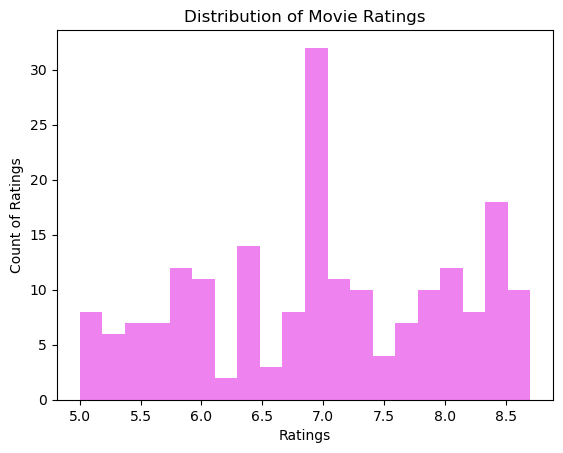

In [52]:
# histogram to visualise the distribution of movie ratings using plt.hist()

plt.hist(movies['rating'], bins= 20, color= 'violet')
plt.title("Distribution of Movie Ratings")
plt.xlabel('Ratings')
plt.ylabel('Count of Ratings')
plt.show()

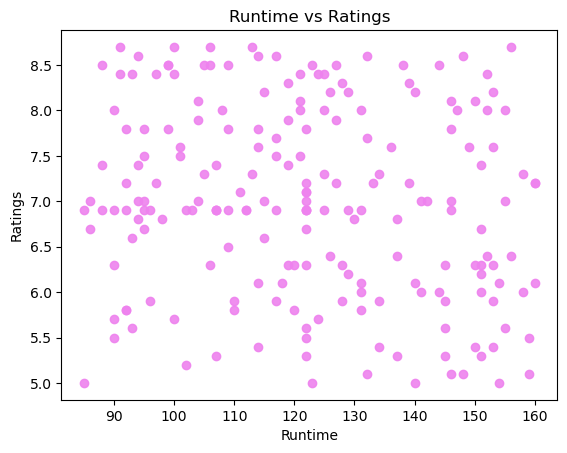

In [53]:
# scatter plot to show the relationship between runtime and rating using plt.scatter()

plt.scatter(movies['runtime'], movies['rating'], color= 'violet', marker= 'o', alpha= 0.9)
plt.title('Runtime vs Ratings')
plt.xlabel('Runtime')
plt.ylabel('Ratings')
plt.show()

In [54]:
# bar chart to compare the average rating of movies in different genres using plt.bar()

average_rating= movies.groupby('genre')['rating'].mean()
average_rating

genre
Action     6.806897
Comedy     7.155556
Drama      7.078788
Horror     6.869697
Romance    7.086486
Sci-Fi     6.896875
Name: rating, dtype: float64

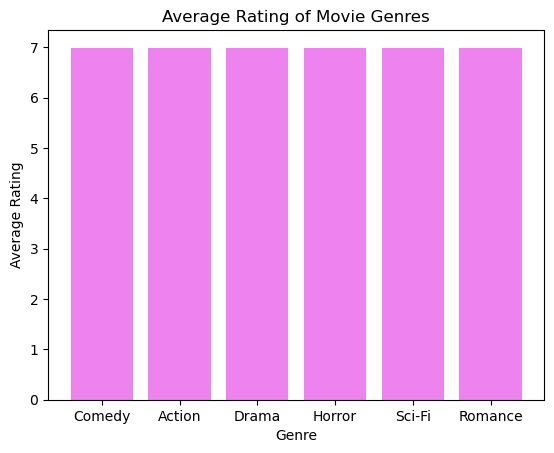

In [55]:
plt.bar(movies['genre'], movies['rating'].mean(), color= 'violet')
plt.title("Average Rating of Movie Genres")
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.show()

In [18]:
# Create visualizations using Matplotlib, highlighting insisghts from the data (add titles, labels, & legends)

movies.columns

Index(['title', 'release_year', 'genre', 'runtime', 'rating'], dtype='object')

In [57]:
num_of_movie_per_year= movies.groupby('release_year')['release_year'].count()
num_of_movie_per_year

release_year
2008    13
2009    10
2010     9
2011    16
2012    13
2013    17
2014     8
2015    17
2016    17
2017    17
2018    15
2019    11
2020    14
2021    23
Name: release_year, dtype: int64

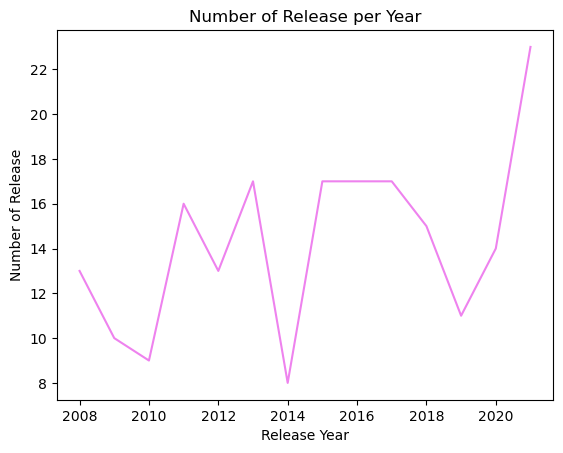

In [58]:
plt.plot(num_of_movie_per_year,  color= 'violet')
plt.title("Number of Release per Year")
plt.xlabel('Release Year')
plt.ylabel('Number of Release')
plt.show()

In [59]:
movies['genre'].unique()

num_of_genres= movies['genre'].value_counts()
num_of_genres

genre
Romance    37
Comedy     36
Drama      33
Horror     33
Sci-Fi     32
Action     29
Name: count, dtype: int64

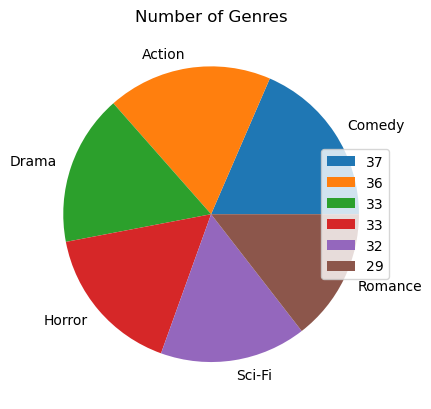

In [60]:
plt.pie(num_of_genres, labels= movies['genre'].unique())
plt.title('Number of Genres')
plt.legend(num_of_genres, loc= 'center right')
plt.show()